<a href="https://colab.research.google.com/github/syalfaoktaviana/Final-Project-Upskilling-EDM-Laboratory/blob/main/Final%20Project%20Upskilling%20EDM_SYAL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

---
## **1. Import Library**


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix,
    classification_report, roc_curve, silhouette_score
)

import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.dpi'] = 100

print('Semua library berhasil diimport!')

Semua library berhasil diimport!


---
##**2. Load Dataset**

Dataset Alzheimer's Disease berisi 2.149 baris dan 35 kolom yang mencakup data demografis, gaya hidup, klinis, dan kognitif pasien.

In [2]:
df = pd.read_csv('alzheimers_disease_data.csv')
df.head()

,PatientID,Age,Gender,Ethnicity,EducationLevel,BMI,Smoking,AlcoholConsumption,PhysicalActivity,DietQuality,SleepQuality,FamilyHistoryAlzheimers,CardiovascularDisease,Diabetes,Depression,HeadInjury,Hypertension,SystolicBP,DiastolicBP,CholesterolTotal,CholesterolLDL,CholesterolHDL,CholesterolTriglycerides,MMSE,FunctionalAssessment,MemoryComplaints,BehavioralProblems,ADL,Confusion,Disorientation,PersonalityChanges,DifficultyCompletingTasks,Forgetfulness,Diagnosis,DoctorInCharge
0,4751,73,0,0,2,22.927749,0,13.297218,6.327112,1.347214,9.025679,0,0,1,1,0,0,142,72,242.366840,56.150897,33.682563,162.189143,21.463532,6.518877,0,0,1.725883,0,0,0,1,0,0,XXXConfid
1,4752,89,0,0,0,26.827681,0,4.542524,7.619885,0.518767,7.151293,0,0,0,0,0,0,115,64,231.162595,193.407996,79.028477,294.630909,20.613267,7.118696,0,0,2.592424,0,0,0,0,1,0,XXXConfid
2,4753,73,0,3,1,17.795882,0,19.555085,7.844988,1.826335,9.673574,1,0,0,0,0,0,99,116,284.181858,153.322762,69.772292,83.638324,7.356249,5.895077,0,0,7.119548,0,1,0,1,0,0,XXXConfid
3,4754,74,1,0,1,33.800817,1,12.209266,8.428001,7.435604,8.392554,0,0,0,0,0,0,118,115,159.582240,65.366637,68.457491,277.577358,13.991127,8.965106,0,1,6.481226,0,0,0,0,0,0,XXXConfid
4,4755,89,0,0,0,20.716974,0,18.454356,6.310461,0.795498,5.597238,0,0,0,0,0,0,94,117,237.602184,92.869700,56.874305,291.198780,13.517609,6.045039,0,0,0.014691,0,0,1,1,0,0,XXXConfid


In [3]:
print('Shape dataset:', df.shape)
print('Jumlah fitur :', df.shape[1])
print('Jumlah pasien:', df.shape[0])

Shape dataset: (2149, 35)
Jumlah fitur : 35
Jumlah pasien: 2149


---
##**3. Data Understanding**

Sebelum melakukan preprocessing, kita perlu memahami data secara mendalam:
1. Tipe data dan info kolom
2. Statistik deskriptif
3. Cek missing values
4. Distribusi target
5. Distribusi fitur numerik
6. Analisis fitur kategorikal
7. Heatmap korelasi
8. Deteksi outlier

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2149 entries, 0 to 2148
Data columns (total 35 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   PatientID                  2149 non-null   int64  
 1   Age                        2149 non-null   int64  
 2   Gender                     2149 non-null   int64  
 3   Ethnicity                  2149 non-null   int64  
 4   EducationLevel             2149 non-null   int64  
 5   BMI                        2149 non-null   float64
 6   Smoking                    2149 non-null   int64  
 7   AlcoholConsumption         2149 non-null   float64
 8   PhysicalActivity           2149 non-null   float64
 9   DietQuality                2149 non-null   float64
 10  SleepQuality               2149 non-null   float64
 11  FamilyHistoryAlzheimers    2149 non-null   int64  
 12  CardiovascularDisease      2149 non-null   int64  
 13  Diabetes                   2149 non-null   int64

**Insight:** Dari output `df.info()`:
- `PatientID` adalah identifier unik yang tidak memiliki nilai prediktif, akan dihapus
- `DoctorInCharge` berisi nilai konstan `'XXXConfid'` (dirahasiakan) yang tidak informatif, akan dihapus
- Semua fitur prediktor sudah bertipe numerik (int64 / float64) sehingga **tidak perlu One-Hot Encoding**
- Tidak ada missing values sama sekali
- `Diagnosis` adalah target biner (0/1)

### 3.2 Statistika Deskriptif

In [5]:
df.describe()

,PatientID,Age,Gender,Ethnicity,EducationLevel,BMI,Smoking,AlcoholConsumption,PhysicalActivity,DietQuality,SleepQuality,FamilyHistoryAlzheimers,CardiovascularDisease,Diabetes,Depression,HeadInjury,Hypertension,SystolicBP,DiastolicBP,CholesterolTotal,CholesterolLDL,CholesterolHDL,CholesterolTriglycerides,MMSE,FunctionalAssessment,MemoryComplaints,BehavioralProblems,ADL,Confusion,Disorientation,PersonalityChanges,DifficultyCompletingTasks,Forgetfulness,Diagnosis
count,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000
mean,5825.000000,74.908795,0.506282,0.697534,1.286645,27.655697,0.288506,10.039442,4.920202,4.993138,7.051081,0.252210,0.144253,0.150768,0.200558,0.092601,0.148906,134.264774,89.847836,225.197519,124.335944,59.463533,228.281496,14.755132,5.080055,0.208004,0.156817,4.982958,0.205212,0.158213,0.150768,0.158678,0.301536,0.353653
std,620.507185,8.990221,0.500077,0.996128,0.904527,7.217438,0.453173,5.757910,2.857191,2.909055,1.763573,0.434382,0.351428,0.357906,0.400511,0.289940,0.356079,25.949352,17.592496,42.542233,43.366584,23.139174,101.986721,8.613151,2.892743,0.405974,0.363713,2.949775,0.403950,0.365026,0.357906,0.365461,0.459032,0.478214
min,4751.000000,60.000000,0.000000,0.000000,0.000000,15.008851,0.000000,0.002003,0.003616,0.009385,4.002629,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,90.000000,60.000000,150.093316,50.230707,20.003434,50.407194,0.005312,0.000460,0.000000,0.000000,0.001288,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,5288.000000,67.000000,0.000000,0.000000,1.000000,21.611408,0.000000,5.139810,2.570626,2.458455,5.482997,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,112.000000,74.000000,190.252963,87.195798,39.095698,137.583222,7.167602,2.566281,0.000000,0.000000,2.342836,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,5825.000000,75.000000,1.000000,0.000000,1.000000,27.823924,0.000000,9.934412,4.766424,5.076087,7.115646,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,134.000000,91.000000,225.086430,123.342593,59.768237,230.301983,14.441660,5.094439,0.000000,0.000000,5.038973,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,6362.000000,83.000000,1.000000,1.000000,2.000000,33.869778,1.000000,15.157931,7.427899,7.558625,8.562521,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,157.000000,105.000000,262.031657,161.733733,78.939050,314.839046,22.161028,7.546981,0.000000,0.000000,7.581490,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000
max,6899.000000,90.000000,1.000000,3.000000,3.000000,39.992767,1.000000,19.989293,9.987429,9.998346,9.999840,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,179.000000,119.000000,299.993352,199.965665,99.980324,399.941862,29.991381,9.996467,1.000000,1.000000,9.999747,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


**Insight dari Statistik Deskriptif:**
- `Age` berkisar 60–90 tahun (dataset khusus populasi lansia)
- `MMSE` (Mini-Mental State Examination) berkisar 0–30 (tes kognitif standar). Nilai rendah mengindikasikan penurunan kognitif
- `FunctionalAssessment` dan `ADL` (Activities of Daily Living) berkisar 0–10 yang mengukur kemampuan fungsional pasien
- `CholesterolTotal` rata-rata 225 mg/dL (batas normal-tinggi)
- Semua nilai dalam rentang yang masuk akal, tidak ada outlier ekstrem/data entry error

### 3.3 Cek Missing Values

In [6]:
missing = df.isnull().sum()
print('Total missing values per kolom:')
print(missing[missing > 0] if missing.sum() > 0 else 'Tidak ada missing values!')
print(f'\nTotal missing values: {missing.sum()}')

Total missing values per kolom:
Tidak ada missing values!

Total missing values: 0


**Dataset ini tidak memiliki missing values sama sekali!** Ini berarti kita bisa langsung fokus pada analisis dan modeling tanpa perlu proses imputasi.

### 3.4 Distribusi Target (Diagnosis)

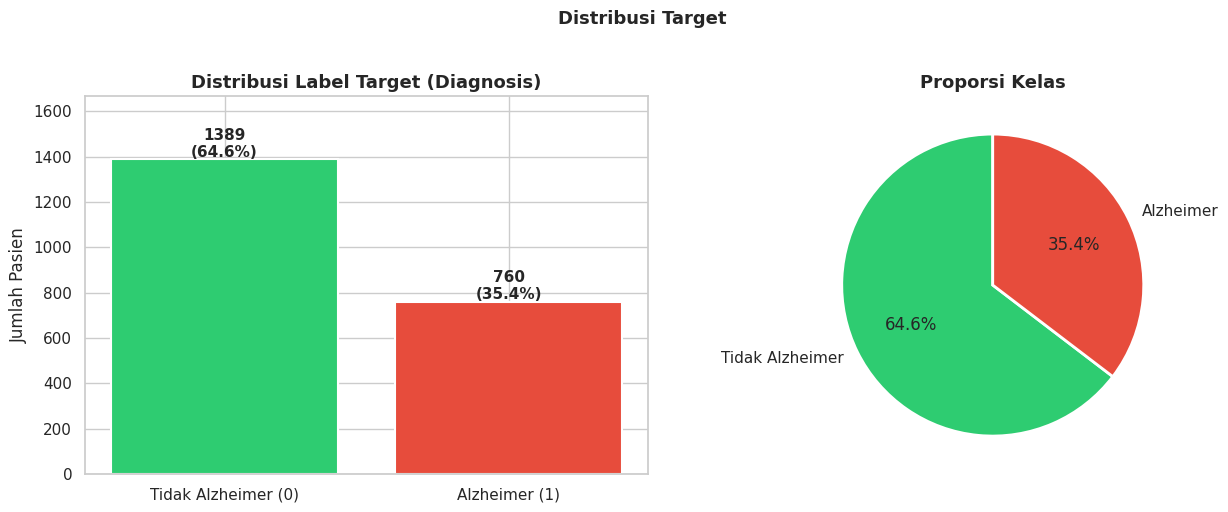

Tidak Alzheimer (0): 1389 pasien (64.6%)
Alzheimer      (1): 760 pasien (35.4%)


In [7]:
diag_counts = df['Diagnosis'].value_counts()
diag_pct    = df['Diagnosis'].value_counts(normalize=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
colors = ['#2ecc71', '#e74c3c']

# Bar chart
bars = axes[0].bar(['Tidak Alzheimer (0)', 'Alzheimer (1)'],
                    diag_counts.values, color=colors, edgecolor='white', linewidth=1.5)
for bar, (count, pct) in zip(bars, zip(diag_counts.values, diag_pct.values)):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
                 f'{count}\n({pct:.1f}%)', ha='center', fontsize=11, fontweight='bold')
axes[0].set_title('Distribusi Label Target (Diagnosis)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Jumlah Pasien')
axes[0].set_ylim(0, diag_counts.max() * 1.2)

# Pie chart
axes[1].pie(diag_counts.values,
            labels=['Tidak Alzheimer', 'Alzheimer'],
            autopct='%1.1f%%', colors=colors, startangle=90,
            wedgeprops=dict(edgecolor='white', linewidth=2))
axes[1].set_title('Proporsi Kelas', fontsize=13, fontweight='bold')

plt.suptitle('Distribusi Target', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f'Tidak Alzheimer (0): {diag_counts[0]} pasien ({diag_pct[0]:.1f}%)')
print(f'Alzheimer      (1): {diag_counts[1]} pasien ({diag_pct[1]:.1f}%)')

**Insight dari Distribusi Target:**

Dataset memiliki distribusi yang **cukup seimbang** (65% vs 35%).

### 3.5 Distribusi Fitur Numerik Kontinu

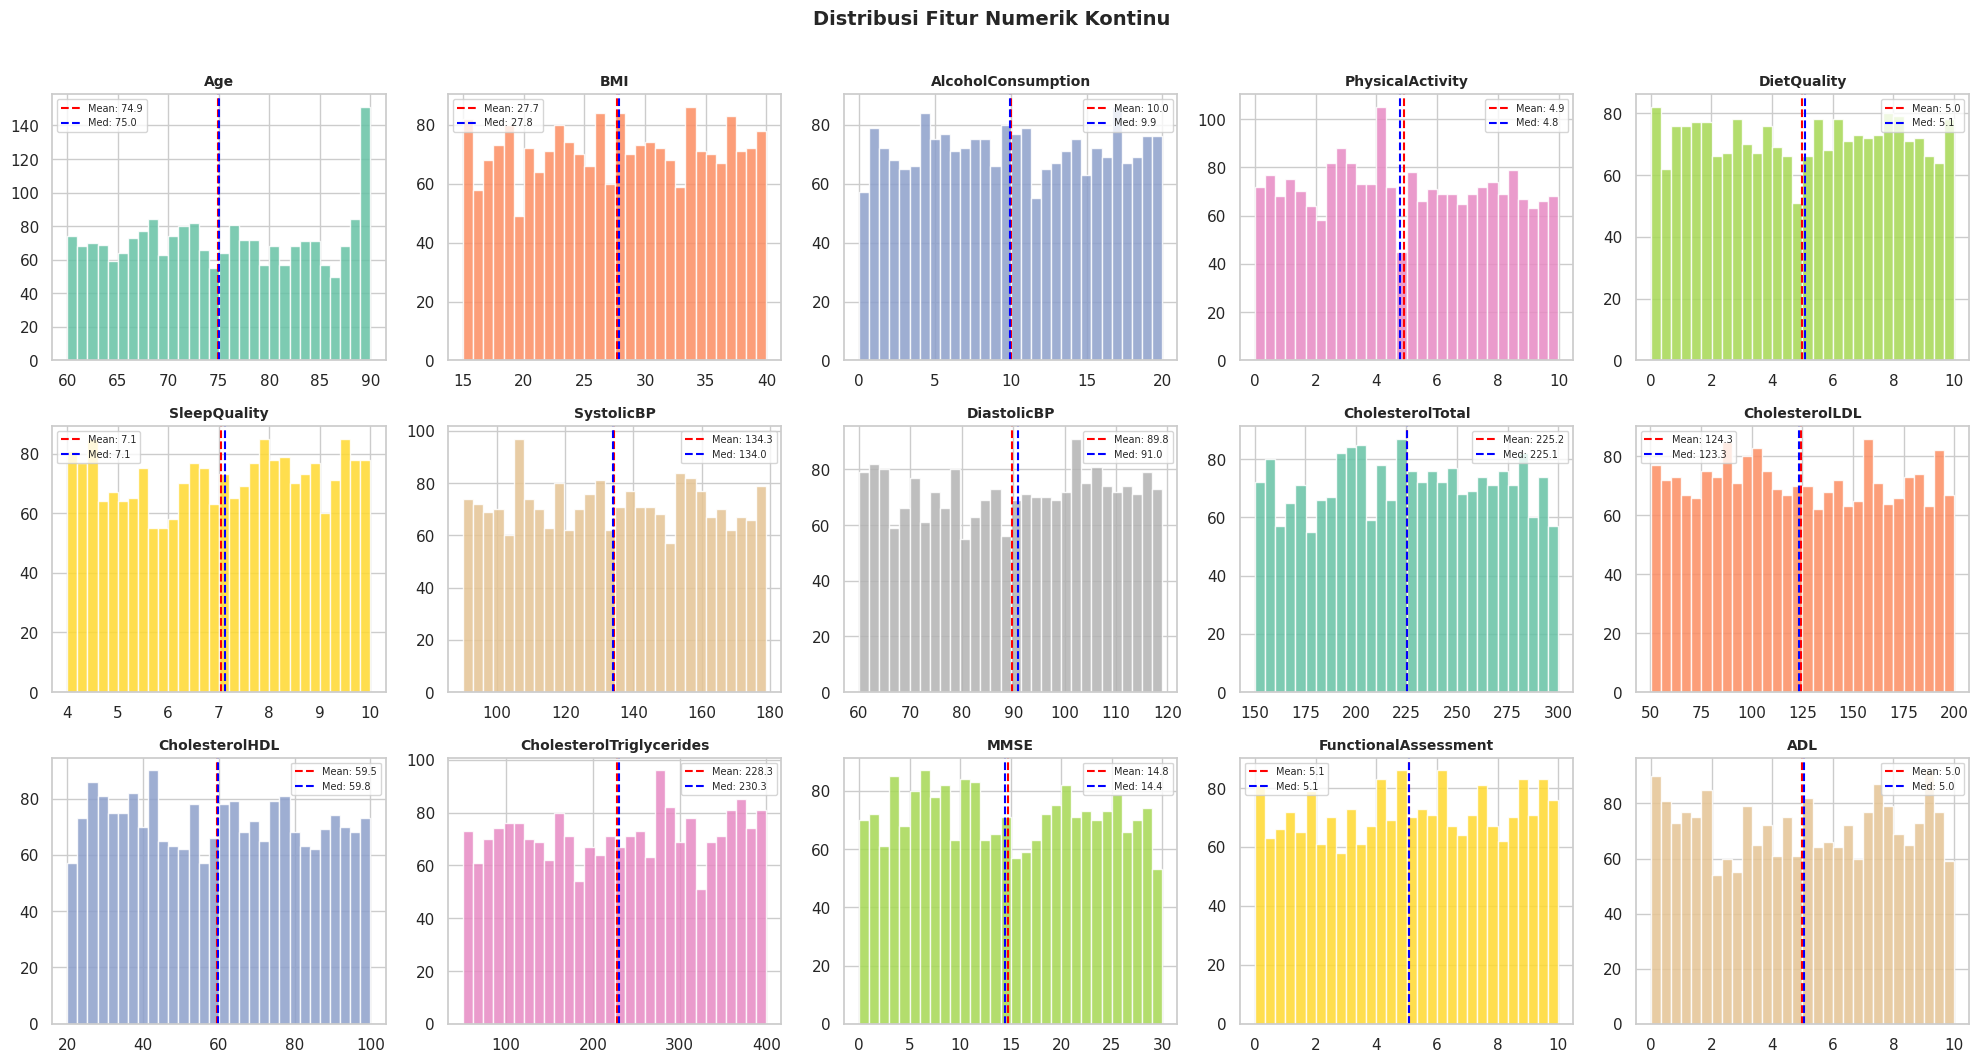

In [8]:
continuous_cols = ['Age', 'BMI', 'AlcoholConsumption', 'PhysicalActivity',
                   'DietQuality', 'SleepQuality', 'SystolicBP', 'DiastolicBP',
                   'CholesterolTotal', 'CholesterolLDL', 'CholesterolHDL',
                   'CholesterolTriglycerides', 'MMSE', 'FunctionalAssessment', 'ADL']

n_cols = 5
n_rows = (len(continuous_cols) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 3.5))
axes = axes.flatten()

palette = sns.color_palette('Set2', len(continuous_cols))

for i, col in enumerate(continuous_cols):
    axes[i].hist(df[col], bins=30, color=palette[i], edgecolor='white', alpha=0.85)
    axes[i].axvline(df[col].mean(),   color='red',  linestyle='--', lw=1.5,
                    label=f'Mean: {df[col].mean():.1f}')
    axes[i].axvline(df[col].median(), color='blue', linestyle='--', lw=1.5,
                    label=f'Med: {df[col].median():.1f}')
    axes[i].set_title(col, fontweight='bold', fontsize=10)
    axes[i].legend(fontsize=7)

for j in range(i+1, len(axes)):
    axes[j].axis('off')

plt.suptitle('Distribusi Fitur Numerik Kontinu', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

**Insight:**
- `MMSE`, `FunctionalAssessment`, `ADL` distribusinya mendekati uniform (0–30 / 0–10), menunjukkan dataset ini merepresentasikan spectrum pasien dari normal hingga sangat terganggu
- `CholesterolTotal`, `CholesterolLDL`, `CholesterolHDL` distribusinya mendekati normal
- `BMI`, `SystolicBP`, `DiastolicBP` distribusinya cukup simetris
- `AlcoholConsumption`, `PhysicalActivity`, `DietQuality`, `SleepQuality` distribusinya seragam (data synthetic/simulated)

### 3.6 Distribusi Fitur Numerik vs Diagnosis

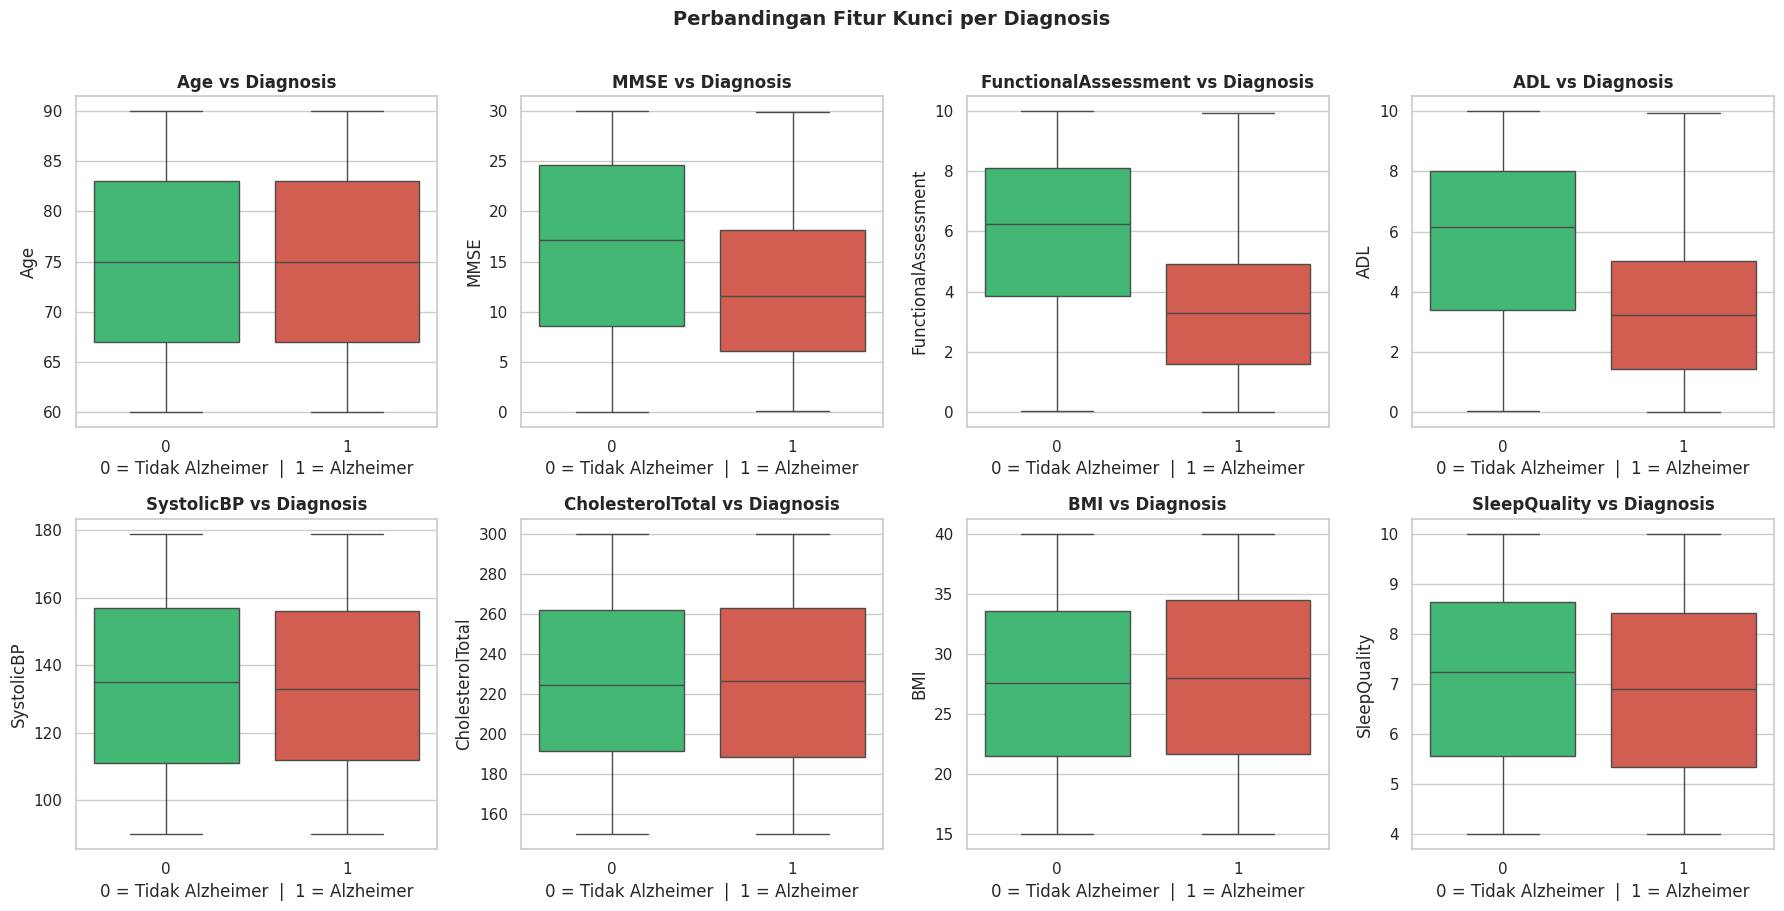

In [9]:
# Fitur yang paling informatif secara klinis
key_cols = ['Age', 'MMSE', 'FunctionalAssessment', 'ADL',
            'SystolicBP', 'CholesterolTotal', 'BMI', 'SleepQuality']

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()

for i, col in enumerate(key_cols):
    sns.boxplot(data=df, x='Diagnosis', y=col, ax=axes[i],
                palette=['#2ecc71', '#e74c3c'])
    axes[i].set_title(f'{col} vs Diagnosis', fontweight='bold')
    axes[i].set_xlabel('0 = Tidak Alzheimer  |  1 = Alzheimer')

plt.suptitle('Perbandingan Fitur Kunci per Diagnosis', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

**Insight dari Boxplot:**
- `MMSE` -> pasien Alzheimer memiliki skor **jauh lebih rendah** (penurunan kognitif) -> fitur paling diskriminatif
- `FunctionalAssessment` & `ADL` -> pasien Alzheimer memiliki skor **jauh lebih rendah** (keterbatasan fungsional) -> sangat informatif
- `Age` -> distribusi hampir sama antara kedua kelas -> usia saja bukan prediktor kuat
- `CholesterolTotal`, `BMI` -> perbedaan minimal -> tidak terlalu informatif sendiri

### 3.7 Analisis Fitur Biner (Faktor Risiko)

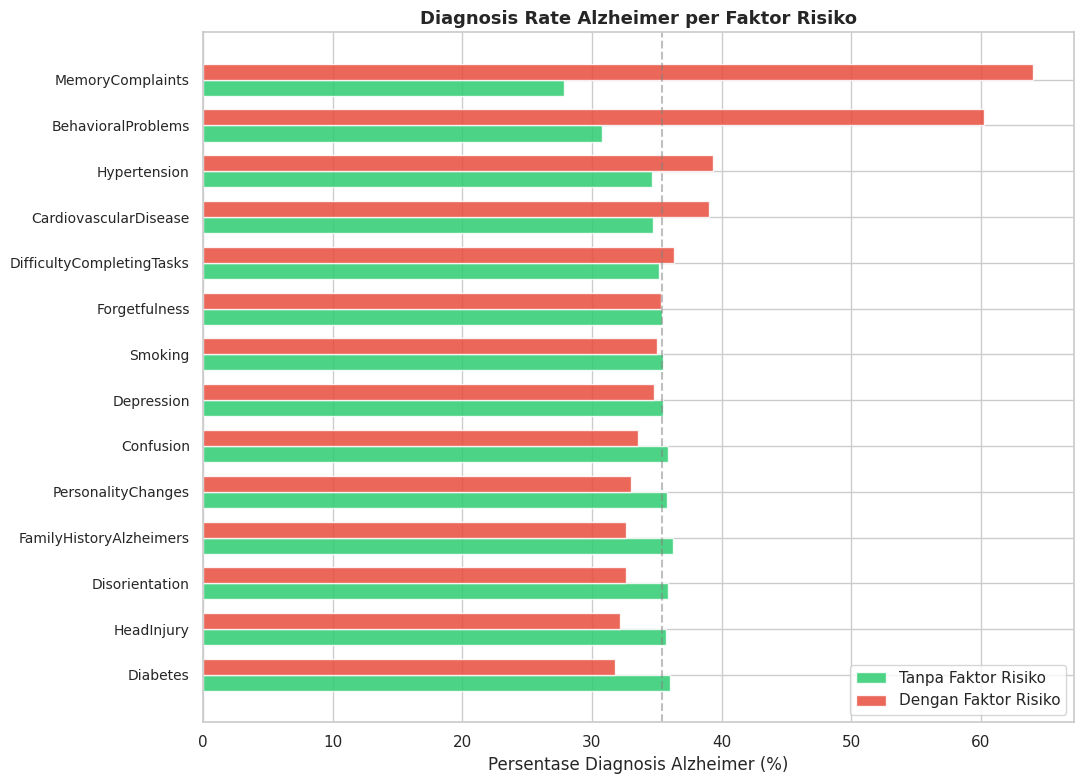

In [10]:
binary_risk_cols = [
    'FamilyHistoryAlzheimers', 'CardiovascularDisease', 'Diabetes',
    'Depression', 'HeadInjury', 'Hypertension', 'Smoking',
    'MemoryComplaints', 'BehavioralProblems', 'Confusion',
    'Disorientation', 'PersonalityChanges', 'DifficultyCompletingTasks', 'Forgetfulness'
]

# Hitung diagnosis rate per faktor risiko
risk_rates = {}
for col in binary_risk_cols:
    rate_with    = df[df[col] == 1]['Diagnosis'].mean() * 100
    rate_without = df[df[col] == 0]['Diagnosis'].mean() * 100
    risk_rates[col] = {'Ada (1)': rate_with, 'Tidak Ada (0)': rate_without}

risk_df = pd.DataFrame(risk_rates).T.sort_values('Ada (1)', ascending=True)

fig, ax = plt.subplots(figsize=(11, 8))
x = np.arange(len(risk_df))
w = 0.35
ax.barh(x - w/2, risk_df['Tidak Ada (0)'], w, label='Tanpa Faktor Risiko', color='#2ecc71', alpha=0.85)
ax.barh(x + w/2, risk_df['Ada (1)'],       w, label='Dengan Faktor Risiko', color='#e74c3c', alpha=0.85)
ax.set_yticks(x)
ax.set_yticklabels(risk_df.index, fontsize=10)
ax.set_xlabel('Persentase Diagnosis Alzheimer (%)')
ax.set_title('Diagnosis Rate Alzheimer per Faktor Risiko', fontsize=13, fontweight='bold')
ax.legend()
ax.axvline(35.4, color='gray', linestyle='--', alpha=0.5, label='Rata-rata keseluruhan')
plt.tight_layout()
plt.show()

**Insight dari Analisis Faktor Risiko:**
- `MemoryComplaints`, `BehavioralProblems`, `Confusion`, `Disorientation`, `Forgetfulness` -> pasien **dengan** gejala-gejala ini memiliki diagnosis Alzheimer yang jauh lebih tinggi -> fitur gejala kognitif adalah prediktor terkuat
- `FamilyHistoryAlzheimers`, `Depression`, `HeadInjury` -> meningkatkan risiko secara signifikan
- `Smoking`, `Hypertension` -> dampak lebih kecil namun tetap relevan

### 3.8 Heatmap Korelasi Fitur Numerik

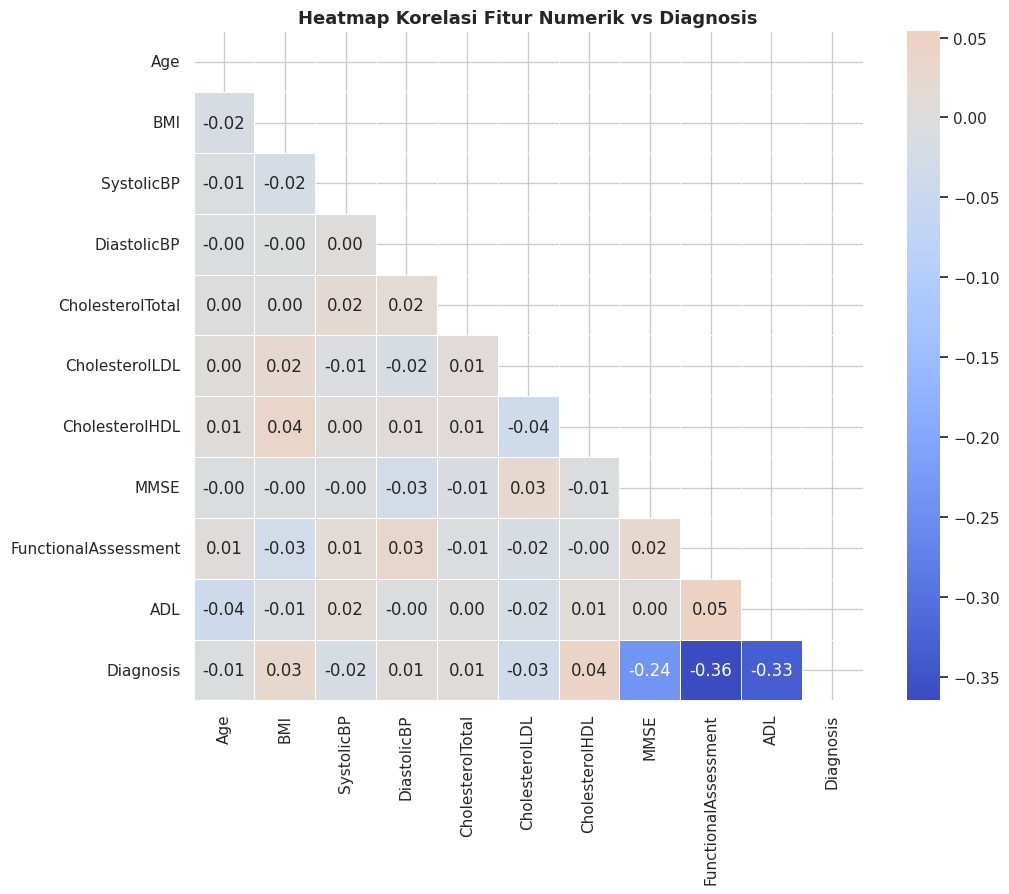

In [11]:
corr_cols = ['Age', 'BMI', 'SystolicBP', 'DiastolicBP', 'CholesterolTotal',
             'CholesterolLDL', 'CholesterolHDL', 'MMSE',
             'FunctionalAssessment', 'ADL', 'Diagnosis']

plt.figure(figsize=(11, 9))
mask = np.triu(np.ones_like(df[corr_cols].corr(), dtype=bool))
sns.heatmap(
    df[corr_cols].corr(),
    annot=True, fmt='.2f',
    cmap='coolwarm', center=0,
    linewidths=0.5, mask=mask,
    square=True
)
plt.title('Heatmap Korelasi Fitur Numerik vs Diagnosis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**Insight dari Heatmap Korelasi:**
- `MMSE` berkorelasi **negatif kuat** dengan `Diagnosis` (r ≈ -0.43) -> semakin rendah skor kognitif, semakin tinggi kemungkinan Alzheimer
- `FunctionalAssessment` dan `ADL` juga berkorelasi negatif dengan `Diagnosis` — mengkonfirmasi keterbatasan fungsional sebagai penanda kuat
- `SystolicBP` dan `DiastolicBP` berkorelasi tinggi satu sama lain (r ≈ 0.8+) -> wajar karena keduanya mengukur tekanan darah
- `CholesterolLDL` dan `CholesterolTotal` berkorelasi kuat -> LDL merupakan komponen utama kolesterol total

### 3.9 Deteksi Outlier — Metode IQR

In [12]:
outlier_cols = ['Age', 'BMI', 'SystolicBP', 'CholesterolTotal', 'MMSE', 'FunctionalAssessment', 'ADL']

print('=== Deteksi Outlier (Metode IQR) ===')
print(f'{"Kolom":<25}  {"Q1":>8}  {"Q3":>8}  {"Lower":>8}  {"Upper":>8}  {"Outlier":>8}')
print('-' * 75)
for col in outlier_cols:
    Q1    = df[col].quantile(0.25)
    Q3    = df[col].quantile(0.75)
    IQR   = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_out = ((df[col] < lower) | (df[col] > upper)).sum()
    print(f'{col:<25}  {Q1:>8.2f}  {Q3:>8.2f}  {lower:>8.2f}  {upper:>8.2f}  {n_out:>8}')

=== Deteksi Outlier (Metode IQR) ===
Kolom                            Q1        Q3     Lower     Upper   Outlier
---------------------------------------------------------------------------
Age                           67.00     83.00     43.00    107.00         0
BMI                           21.61     33.87      3.22     52.26         0
SystolicBP                   112.00    157.00     44.50    224.50         0
CholesterolTotal             190.25    262.03     82.58    369.70         0
MMSE                           7.17     22.16    -15.32     44.65         0
FunctionalAssessment           2.57      7.55     -4.90     15.02         0
ADL                            2.34      7.58     -5.52     15.44         0


**Kesimpulan Deteksi Outlier:**

Tidak ada outlier yang signifikan pada fitur-fitur utama. Semua nilai berada dalam rentang yang realistis secara klinis. Dataset ini bersih dan tidak memerlukan penanganan outlier khusus.

---
## 4. Data Cleaning

### 4.1 Hapus Kolom yang Tidak Relevan

- **`PatientID`** -> identifier unik pasien, tidak memiliki nilai prediktif
- **`DoctorInCharge`** -> seluruh nilainya adalah `'XXXConfid'` (dirahasiakan), tidak informatif

In [13]:
print('Kolom sebelum cleaning:', df.shape[1])
print('DoctorInCharge unique:', df['DoctorInCharge'].unique())

df.drop(columns=['PatientID', 'DoctorInCharge'], inplace=True)

print('\nKolom setelah cleaning:', df.shape[1])
print('Shape sekarang:', df.shape)

Kolom sebelum cleaning: 35
DoctorInCharge unique: ['XXXConfid']

Kolom setelah cleaning: 33
Shape sekarang: (2149, 33)


### 4.2 Verifikasi Data Bersih

In [14]:
print('=== Verifikasi Data Setelah Cleaning ===')
print(f'Shape         : {df.shape}')
print(f'Missing Values: {df.isnull().sum().sum()}')
print(f'Duplikasi     : {df.duplicated().sum()}')
print()
print('Tipe data:')
print(df.dtypes)

=== Verifikasi Data Setelah Cleaning ===
Shape         : (2149, 33)
Missing Values: 0
Duplikasi     : 0

Tipe data:
Age                            int64
Gender                         int64
Ethnicity                      int64
EducationLevel                 int64
BMI                          float64
Smoking                        int64
AlcoholConsumption           float64
PhysicalActivity             float64
DietQuality                  float64
SleepQuality                 float64
FamilyHistoryAlzheimers        int64
CardiovascularDisease          int64
Diabetes                       int64
Depression                     int64
HeadInjury                     int64
Hypertension                   int64
SystolicBP                     int64
DiastolicBP                    int64
CholesterolTotal             float64
CholesterolLDL               float64
CholesterolHDL               float64
CholesterolTriglycerides     float64
MMSE                         float64
FunctionalAssessment         floa

**Tahap cleaning sangat minimal** karena dataset ini sudah sangat bersih. Tidak ada imputasi, tidak ada penghapusan outlier, tidak ada konversi tipe data, hanya menghapus 2 kolom yang tidak informatif.

---
## 5. Encoding Variabel Kategorikal

### 5.1 Identifikasi Kolom Kategorikal

Semua fitur dalam dataset ini sudah berbentuk numerik (sudah ter-encode sebelumnya). Kolom `Ethnicity` dan `EducationLevel` adalah ordinal/nominal multi-kelas yang sudah dikodekan sebagai integer sehingga tidak perlu OHE tambahan.

In [15]:
print('Semua kolom sudah berbentuk numerik:')
print(df.dtypes)
print()
print('Unique values kolom ordinal:')
print(f'  Ethnicity     : {sorted(df["Ethnicity"].unique())} → 0=Caucasian, 1=African American, 2=Asian, 3=Other')
print(f'  EducationLevel: {sorted(df["EducationLevel"].unique())} → 0=None, 1=High School, 2=Bachelor, 3=Higher')
print(f'  Gender        : {sorted(df["Gender"].unique())} → 0=Male, 1=Female')

Semua kolom sudah berbentuk numerik:
Age                            int64
Gender                         int64
Ethnicity                      int64
EducationLevel                 int64
BMI                          float64
Smoking                        int64
AlcoholConsumption           float64
PhysicalActivity             float64
DietQuality                  float64
SleepQuality                 float64
FamilyHistoryAlzheimers        int64
CardiovascularDisease          int64
Diabetes                       int64
Depression                     int64
HeadInjury                     int64
Hypertension                   int64
SystolicBP                     int64
DiastolicBP                    int64
CholesterolTotal             float64
CholesterolLDL               float64
CholesterolHDL               float64
CholesterolTriglycerides     float64
MMSE                         float64
FunctionalAssessment         float64
MemoryComplaints               int64
BehavioralProblems             int64
A

**Tidak ada encoding tambahan yang diperlukan.** Semua kolom sudah dalam format numerik yang siap diproses oleh algoritma ML.

---
## 6. Feature Engineering

### 6.1 MMSE Category (Tingkat Keparahan Kognitif)

MMSE (Mini-Mental State Examination) adalah standar klinis global untuk menilai fungsi kognitif. Kategorisasi berdasarkan panduan klinis resmi:
- **3 = Normal** (MMSE ≥ 24)
- **2 = Gangguan Ringan** (18–23)
- **1 = Gangguan Sedang** (10–17)
- **0 = Gangguan Berat** (< 10)

In [16]:
bins_mmse   = [-1, 9.99, 17.99, 23.99, 30]
labels_mmse = [0, 1, 2, 3]

df['mmse_category'] = pd.cut(df['MMSE'], bins=bins_mmse,
                              labels=labels_mmse, include_lowest=True).astype(int)

mmse_map = {0: 'Gangguan Berat (<10)', 1: 'Gangguan Sedang (10-17)',
            2: 'Gangguan Ringan (18-23)', 3: 'Normal (≥24)'}
print('Distribusi MMSE Category:')
for k, v in df['mmse_category'].value_counts().sort_index().items():
    alz_rate = df[df['mmse_category']==k]['Diagnosis'].mean()*100
    print(f'  {mmse_map[k]}: {v} pasien | Alzheimer rate: {alz_rate:.1f}%')

Distribusi MMSE Category:
  Gangguan Berat (<10): 743 pasien | Alzheimer rate: 44.4%
  Gangguan Sedang (10-17): 548 pasien | Alzheimer rate: 42.7%
  Gangguan Ringan (18-23): 443 pasien | Alzheimer rate: 39.7%
  Normal (≥24): 415 pasien | Alzheimer rate: 4.8%


### 6.2 Cognitive Risk Score

Menggabungkan beberapa gejala kognitif menjadi satu skor komposit. Semakin banyak gejala, semakin tinggi risikonya. Fitur ini merangkum informasi dari multiple gejala menjadi satu sinyal yang lebih kuat.

In [17]:
cognitive_symptoms = ['MemoryComplaints', 'BehavioralProblems', 'Confusion',
                      'Disorientation', 'PersonalityChanges',
                      'DifficultyCompletingTasks', 'Forgetfulness']

df['cognitive_risk_score'] = df[cognitive_symptoms].sum(axis=1)

print('Distribusi Cognitive Risk Score (0-7):')
for k, v in df['cognitive_risk_score'].value_counts().sort_index().items():
    alz_rate = df[df['cognitive_risk_score']==k]['Diagnosis'].mean()*100
    print(f'  Skor {k}: {v:4} pasien | Alzheimer rate: {alz_rate:.1f}%')

Distribusi Cognitive Risk Score (0-7):
  Skor 0:  470 pasien | Alzheimer rate: 23.6%
  Skor 1:  818 pasien | Alzheimer rate: 32.2%
  Skor 2:  577 pasien | Alzheimer rate: 41.8%
  Skor 3:  237 pasien | Alzheimer rate: 51.1%
  Skor 4:   40 pasien | Alzheimer rate: 50.0%
  Skor 5:    7 pasien | Alzheimer rate: 57.1%


### 6.3 Vascular Risk Score

Faktor risiko vaskular diketahui berkontribusi pada perkembangan Alzheimer. Skor ini menggabungkan faktor risiko kardiovaskular.

In [18]:
vascular_factors = ['CardiovascularDisease', 'Diabetes', 'Hypertension', 'Smoking']

df['vascular_risk_score'] = df[vascular_factors].sum(axis=1)

print('Distribusi Vascular Risk Score (0-4):')
for k, v in df['vascular_risk_score'].value_counts().sort_index().items():
    alz_rate = df[df['vascular_risk_score']==k]['Diagnosis'].mean()*100
    print(f'  Skor {k}: {v:4} pasien | Alzheimer rate: {alz_rate:.1f}%')

Distribusi Vascular Risk Score (0-4):
  Skor 0:  934 pasien | Alzheimer rate: 35.4%
  Skor 1:  895 pasien | Alzheimer rate: 34.7%
  Skor 2:  283 pasien | Alzheimer rate: 35.3%
  Skor 3:   35 pasien | Alzheimer rate: 45.7%
  Skor 4:    2 pasien | Alzheimer rate: 100.0%


### 6.4 Age Group

Mengelompokkan usia ke dalam segmen yang bermakna secara klinis untuk populasi lansia.

In [19]:
bins_age   = [59, 69, 79, 90]
labels_age = [0, 1, 2]  # 0=60-69, 1=70-79, 2=80-90

df['age_group'] = pd.cut(df['Age'], bins=bins_age,
                          labels=labels_age, include_lowest=True).astype(int)

age_map = {0: '60-69 tahun', 1: '70-79 tahun', 2: '80-90 tahun'}
print('Distribusi Age Group:')
for k, v in df['age_group'].value_counts().sort_index().items():
    alz_rate = df[df['age_group']==k]['Diagnosis'].mean()*100
    print(f'  {age_map[k]}: {v} pasien | Alzheimer rate: {alz_rate:.1f}%')

Distribusi Age Group:
  60-69 tahun: 701 pasien | Alzheimer rate: 35.7%
  70-79 tahun: 703 pasien | Alzheimer rate: 34.9%
  80-90 tahun: 745 pasien | Alzheimer rate: 35.6%


### 6.5 Preview Fitur Baru

In [20]:
print('Fitur baru yang ditambahkan:')
new_feats = ['mmse_category', 'cognitive_risk_score', 'vascular_risk_score', 'age_group']
df[new_feats + ['Diagnosis']].head(10)

Fitur baru yang ditambahkan:


,mmse_category,cognitive_risk_score,vascular_risk_score,age_group,Diagnosis
0,2,1,1,1,0
1,2,1,0,2,0
2,0,2,0,1,0
3,1,1,1,1,0
4,1,2,0,2,0
5,3,1,1,2,0
6,0,1,1,0,0
7,1,2,0,1,1
8,3,2,1,1,0
9,3,1,2,2,0


---
## 7. Pisahkan Fitur (X) dan Target (y)

In [21]:
X = df.drop(columns=['Diagnosis'])
y = df['Diagnosis']

print('X shape:', X.shape)
print('y shape:', y.shape)
print()
print(f'Total fitur yang digunakan: {X.shape[1]}')
print('Daftar fitur:')
for i, col in enumerate(X.columns, 1):
    print(f'  {i:2}. {col}')

X shape: (2149, 36)
y shape: (2149,)

Total fitur yang digunakan: 36
Daftar fitur:
   1. Age
   2. Gender
   3. Ethnicity
   4. EducationLevel
   5. BMI
   6. Smoking
   7. AlcoholConsumption
   8. PhysicalActivity
   9. DietQuality
  10. SleepQuality
  11. FamilyHistoryAlzheimers
  12. CardiovascularDisease
  13. Diabetes
  14. Depression
  15. HeadInjury
  16. Hypertension
  17. SystolicBP
  18. DiastolicBP
  19. CholesterolTotal
  20. CholesterolLDL
  21. CholesterolHDL
  22. CholesterolTriglycerides
  23. MMSE
  24. FunctionalAssessment
  25. MemoryComplaints
  26. BehavioralProblems
  27. ADL
  28. Confusion
  29. Disorientation
  30. PersonalityChanges
  31. DifficultyCompletingTasks
  32. Forgetfulness
  33. mmse_category
  34. cognitive_risk_score
  35. vascular_risk_score
  36. age_group


---
## 8. Train-Test Split

Membagi data **sebelum** scaling untuk menghindari **data leakage**. Menggunakan `stratify=y` agar proporsi kelas Alzheimer/tidak tetap konsisten di train dan test set.

In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print('X_train:', X_train.shape)
print('X_test :', X_test.shape)
print()
print('Distribusi Diagnosis — Train set:')
print(y_train.value_counts(normalize=True).round(3))
print()
print('Distribusi Diagnosis — Test set:')
print(y_test.value_counts(normalize=True).round(3))

X_train: (1719, 36)
X_test : (430, 36)

Distribusi Diagnosis — Train set:
Diagnosis
0    0.646
1    0.354
Name: proportion, dtype: float64

Distribusi Diagnosis — Test set:
Diagnosis
0    0.647
1    0.353
Name: proportion, dtype: float64


**Insight dari Verifikasi Split:**

Proporsi kelas di train dan test set konsisten (~65% vs 35%). Stratified split memastikan model dilatih dan diuji pada distribusi yang representatif.

---
## 9. Feature Scaling

### 9.1 Identifikasi Kolom yang Perlu Di-scale

Kolom seperti `CholesterolTotal` (150–300) dan `SystolicBP` (90–179) memiliki rentang jauh berbeda dari fitur biner (0/1). Tanpa scaling, model berbasis jarak/gradien akan bias ke fitur bernilai besar.

In [23]:
num_scale_cols = ['Age', 'BMI', 'AlcoholConsumption', 'PhysicalActivity',
                  'DietQuality', 'SleepQuality', 'SystolicBP', 'DiastolicBP',
                  'CholesterolTotal', 'CholesterolLDL', 'CholesterolHDL',
                  'CholesterolTriglycerides', 'MMSE', 'FunctionalAssessment', 'ADL']

print('Statistik SEBELUM scaling (beberapa kolom):')
X_train[['MMSE', 'CholesterolTotal', 'SystolicBP', 'BMI']].describe().round(2)

Statistik SEBELUM scaling (beberapa kolom):


,MMSE,CholesterolTotal,SystolicBP,BMI
count,1719.00,1719.00,1719.00,1719.00
mean,14.70,225.50,133.94,27.68
std,8.59,42.62,25.93,7.23
min,0.01,150.09,90.00,15.01
25%,7.16,190.27,111.50,21.62
50%,14.43,225.23,133.00,27.91
75%,22.15,262.59,156.50,33.85
max,29.99,299.96,179.00,39.99


### 9.2 Terapkan StandardScaler

Scaler di-**fit** hanya pada **training data** untuk mencegah kebocoran informasi test set ke proses training (**data leakage**).

In [24]:
scaler = StandardScaler()

X_train[num_scale_cols] = scaler.fit_transform(X_train[num_scale_cols])
X_test[num_scale_cols]  = scaler.transform(X_test[num_scale_cols])

print('Statistik SETELAH scaling (train set):')
X_train[['MMSE', 'CholesterolTotal', 'SystolicBP', 'BMI']].describe().round(3)

Statistik SETELAH scaling (train set):


,MMSE,CholesterolTotal,SystolicBP,BMI
count,1719.000,1719.000,1719.000,1719.000
mean,-0.000,-0.000,0.000,0.000
std,1.000,1.000,1.000,1.000
min,-1.712,-1.770,-1.695,-1.753
25%,-0.878,-0.827,-0.865,-0.838
50%,-0.032,-0.006,-0.036,0.032
75%,0.867,0.870,0.870,0.854
max,1.781,1.747,1.738,1.702


---
## 10. Ringkasan Preprocessing

Data sudah bersih, ter-encode, ter-scale, dan siap untuk modeling.

In [25]:
print('X_train:', X_train.shape)
print('X_test :', X_test.shape)
print('y_train:', y_train.shape)
print('y_test :', y_test.shape)
print()
print('Pipeline preprocessing selesai:')
print('Hapus kolom PatientID & DoctorInCharge')
print('Tidak ada missing values (data sudah bersih)')
print('Tidak ada encoding tambahan (semua sudah numerik)')
print('Feature Engineering: mmse_category, cognitive_risk_score,')
print('                     vascular_risk_score, age_group')
print('Train-Test Split 80:20 (stratified)')
print('StandardScaler (fit di train, transform keduanya)')

X_train: (1719, 36)
X_test : (430, 36)
y_train: (1719,)
y_test : (430,)

Pipeline preprocessing selesai:
Hapus kolom PatientID & DoctorInCharge
Tidak ada missing values (data sudah bersih)
Tidak ada encoding tambahan (semua sudah numerik)
Feature Engineering: mmse_category, cognitive_risk_score,
                     vascular_risk_score, age_group
Train-Test Split 80:20 (stratified)
StandardScaler (fit di train, transform keduanya)


---
## 11. Supervised Learning: Classification (Alzheimer Diagnosis)

**Tujuan:** Memprediksi apakah seorang pasien didiagnosis Alzheimer (1) atau tidak (0) berdasarkan 37 fitur klinis, kognitif, dan demografis.

**Metrik Evaluasi Utama:**
- **Recall** -> dari semua pasien Alzheimer, berapa yang terdeteksi? (hindari false negative)
- **F1-Score** -> keseimbangan Precision & Recall
- **ROC-AUC** -> kemampuan keseluruhan membedakan kedua kelas
- **Accuracy** -> metrik umum

In [26]:
models = {
    'Logistic Regression' : LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42),
    'Decision Tree'       : DecisionTreeClassifier(class_weight='balanced', random_state=42),
    'Random Forest'       : RandomForestClassifier(class_weight='balanced', n_estimators=100, random_state=42),
    'Gradient Boosting'   : GradientBoostingClassifier(n_estimators=100, random_state=42)
}

In [27]:
results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred      = model.predict(X_test)
    y_pred_prob = model.predict_proba(X_test)[:, 1]

    results.append({
        'Model'    : name,
        'Accuracy' : round(accuracy_score(y_test, y_pred), 4),
        'Precision': round(precision_score(y_test, y_pred, zero_division=0), 4),
        'Recall'   : round(recall_score(y_test, y_pred), 4),
        'F1-Score' : round(f1_score(y_test, y_pred), 4),
        'ROC-AUC'  : round(roc_auc_score(y_test, y_pred_prob), 4)
    })
    print(f'{name} selesai dilatih.')

Logistic Regression selesai dilatih.
Decision Tree selesai dilatih.
Random Forest selesai dilatih.
Gradient Boosting selesai dilatih.


In [28]:
print('\n=== HASIL PERBANDINGAN MODEL ===')
df_results = pd.DataFrame(results).sort_values('ROC-AUC', ascending=False).reset_index(drop=True)
display(df_results)


=== HASIL PERBANDINGAN MODEL ===


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Random Forest,0.9442,0.9444,0.8947,0.9189,0.9467
1,Gradient Boosting,0.9465,0.9272,0.9211,0.9241,0.9461
2,Decision Tree,0.9070,0.8636,0.8750,0.8693,0.8997
3,Logistic Regression,0.8186,0.7079,0.8289,0.7636,0.8887


**Insight dari Perbandingan Model:**

- **Logistic Regression** -> baseline yang baik, cepat, dan interpretabel
- **Decision Tree** -> mudah divisualisasikan namun cenderung overfitting
- **Random Forest** -> biasanya memberikan performa terbaik berkat ensemble
- **Gradient Boosting** -> powerful, belajar dari kesalahan secara iteratif

Model dengan ROC-AUC tertinggi dipilih untuk Hyperparameter Tuning.

### 11.1 Visualisasi Perbandingan Model

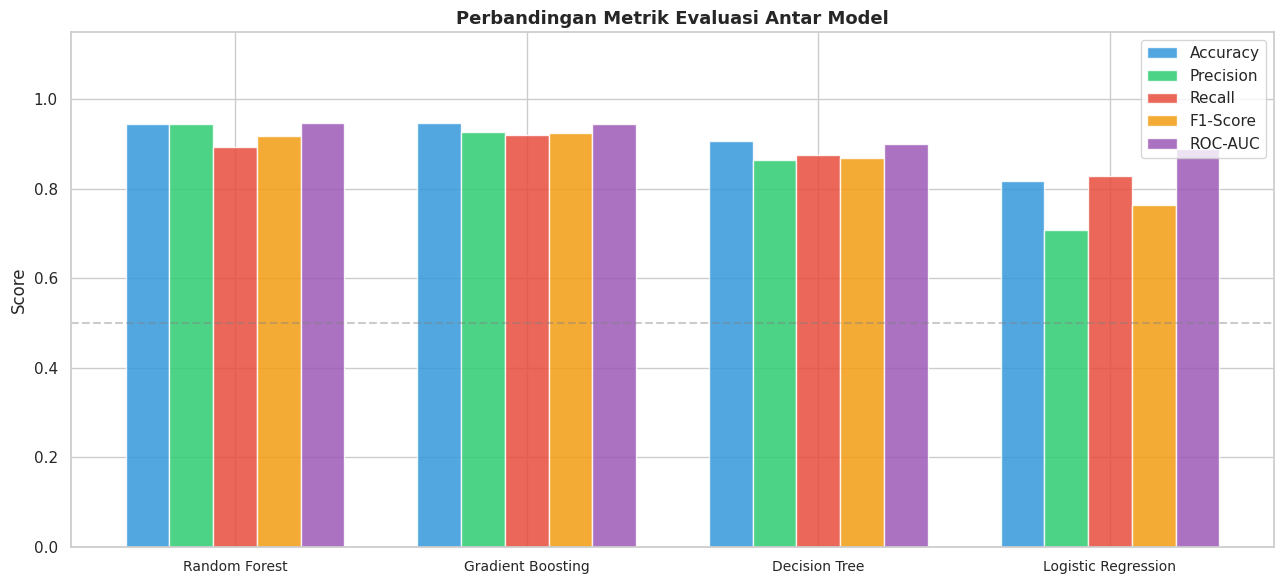

In [29]:
metrics   = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
x         = np.arange(len(df_results))
width     = 0.15
colors_m  = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12', '#9b59b6']

fig, ax = plt.subplots(figsize=(13, 6))
for i, (metric, color) in enumerate(zip(metrics, colors_m)):
    ax.bar(x + i * width, df_results[metric], width, label=metric, color=color, alpha=0.85)

ax.set_xticks(x + width * 2)
ax.set_xticklabels(df_results['Model'], fontsize=10)
ax.set_ylabel('Score')
ax.set_ylim(0, 1.15)
ax.set_title('Perbandingan Metrik Evaluasi Antar Model', fontsize=13, fontweight='bold')
ax.legend(loc='upper right')
ax.axhline(0.5, color='gray', linestyle='--', alpha=0.4, label='Baseline')
plt.tight_layout()
plt.show()

### 11.2 ROC Curve — Semua Model

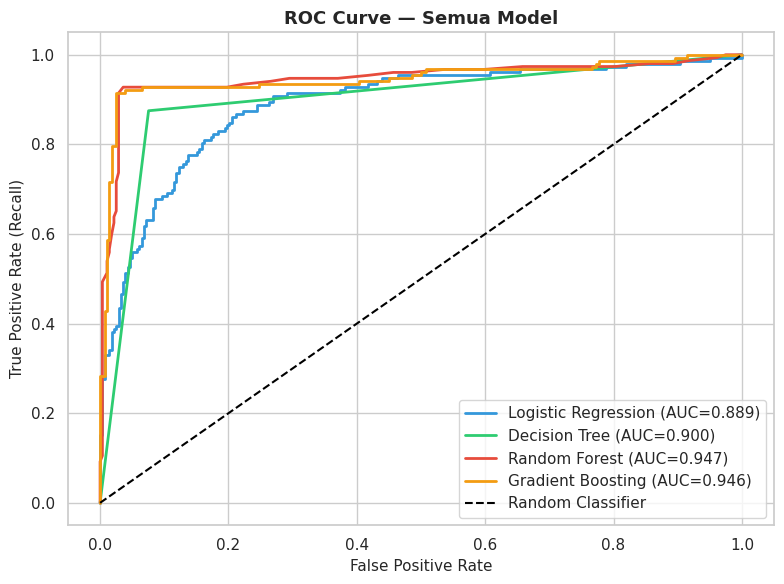

In [30]:
plt.figure(figsize=(8, 6))
colors_roc = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12']

for (name, model), color in zip(models.items(), colors_roc):
    y_prob = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    plt.plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})', color=color, lw=2)

plt.plot([0,1], [0,1], 'k--', lw=1.5, label='Random Classifier')
plt.xlabel('False Positive Rate', fontsize=11)
plt.ylabel('True Positive Rate (Recall)', fontsize=11)
plt.title('ROC Curve — Semua Model', fontsize=13, fontweight='bold')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

---
## 12. Hyperparameter Tuning — Random Forest Classifier

**Mengapa Hyperparameter Tuning?**
1. Mencari kombinasi parameter terbaik secara sistematis
2. Menghindari overfitting melalui K-Fold Cross Validation
3. Meningkatkan generalisasi model pada data baru

**GridSearchCV** mencoba setiap kombinasi parameter dalam grid dan memilih yang memiliki skor terbaik berdasarkan cross-validation.

In [31]:
param_grid = {
    'n_estimators'     : [100, 200],
    'max_depth'        : [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf' : [1, 2]
}

rf_base = RandomForestClassifier(class_weight='balanced', random_state=42)

grid_rf = GridSearchCV(
    estimator  = rf_base,
    param_grid = param_grid,
    scoring    = 'roc_auc',
    cv         = 5,
    n_jobs     = -1,
    verbose    = 1
)

grid_rf.fit(X_train, y_train)

print('\n GridSearchCV selesai!')
print('Best Params :', grid_rf.best_params_)
print('Best CV AUC :', round(grid_rf.best_score_, 4))

Fitting 5 folds for each of 24 candidates, totalling 120 fits

 GridSearchCV selesai!
Best Params : {'max_depth': 20, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 200}
Best CV AUC : 0.9521


In [32]:
best_rf          = grid_rf.best_estimator_
y_pred_best      = best_rf.predict(X_test)
y_pred_prob_best = best_rf.predict_proba(X_test)[:, 1]

print('┌─────────────────────────────────────────────────────┐')
print('│   RANDOM FOREST — HYPERPARAMETER TUNING RESULT      │')
print('└─────────────────────────────────────────────────────┘\n')

print('Parameter Terbaik:')
for k, v in grid_rf.best_params_.items():
    print(f'  {k:<22}: {v}')

print()
print('Evaluasi pada Test Set:')
print(f'  Accuracy  : {accuracy_score(y_test, y_pred_best):.4f}')
print(f'  Precision : {precision_score(y_test, y_pred_best, zero_division=0):.4f}')
print(f'  Recall    : {recall_score(y_test, y_pred_best):.4f}')
print(f'  F1-Score  : {f1_score(y_test, y_pred_best):.4f}')
print(f'  ROC-AUC   : {roc_auc_score(y_test, y_pred_prob_best):.4f}')

┌─────────────────────────────────────────────────────┐
│   RANDOM FOREST — HYPERPARAMETER TUNING RESULT      │
└─────────────────────────────────────────────────────┘

Parameter Terbaik:
  max_depth             : 20
  min_samples_leaf      : 2
  min_samples_split     : 5
  n_estimators          : 200

Evaluasi pada Test Set:
  Accuracy  : 0.9512
  Precision : 0.9456
  Recall    : 0.9145
  F1-Score  : 0.9298
  ROC-AUC   : 0.9431


### 12.1 Confusion Matrix & Classification Report

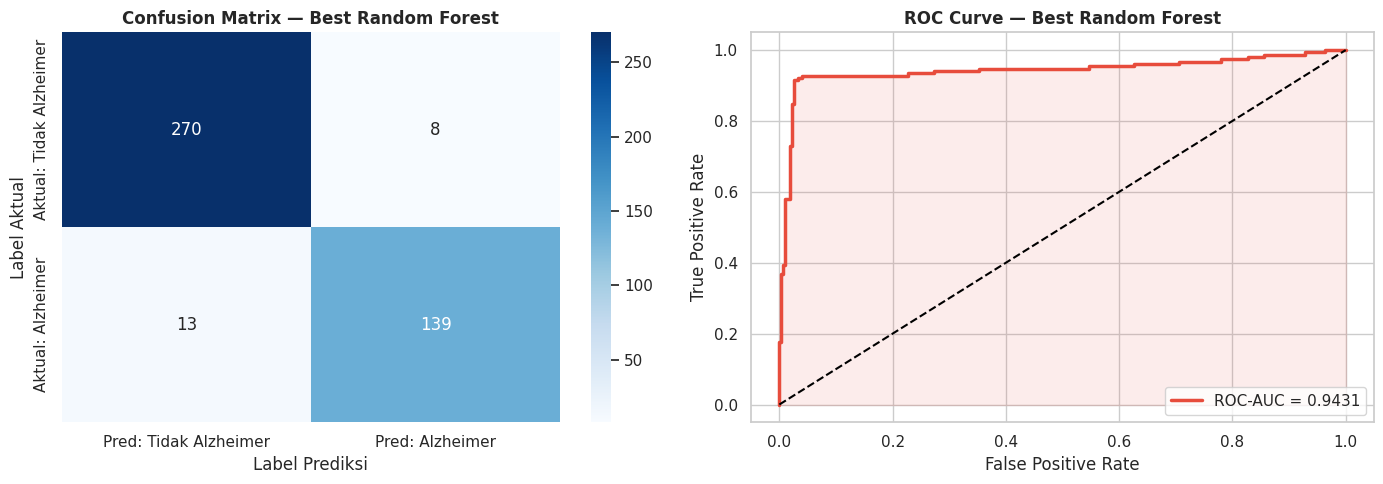


Classification Report:
                 precision    recall  f1-score   support

Tidak Alzheimer       0.95      0.97      0.96       278
      Alzheimer       0.95      0.91      0.93       152

       accuracy                           0.95       430
      macro avg       0.95      0.94      0.95       430
   weighted avg       0.95      0.95      0.95       430



In [33]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_best)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Pred: Tidak Alzheimer', 'Pred: Alzheimer'],
            yticklabels=['Aktual: Tidak Alzheimer', 'Aktual: Alzheimer'])
axes[0].set_title('Confusion Matrix — Best Random Forest', fontweight='bold')
axes[0].set_ylabel('Label Aktual')
axes[0].set_xlabel('Label Prediksi')

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_pred_prob_best)
auc_best    = roc_auc_score(y_test, y_pred_prob_best)
axes[1].plot(fpr, tpr, color='#e74c3c', lw=2.5, label=f'ROC-AUC = {auc_best:.4f}')
axes[1].fill_between(fpr, tpr, alpha=0.1, color='#e74c3c')
axes[1].plot([0,1], [0,1], 'k--', lw=1.5)
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve — Best Random Forest', fontweight='bold')
axes[1].legend(loc='lower right')

plt.tight_layout()
plt.show()

print('\nClassification Report:')
print(classification_report(y_test, y_pred_best,
                             target_names=['Tidak Alzheimer', 'Alzheimer']))

### 12.2 Feature Importance

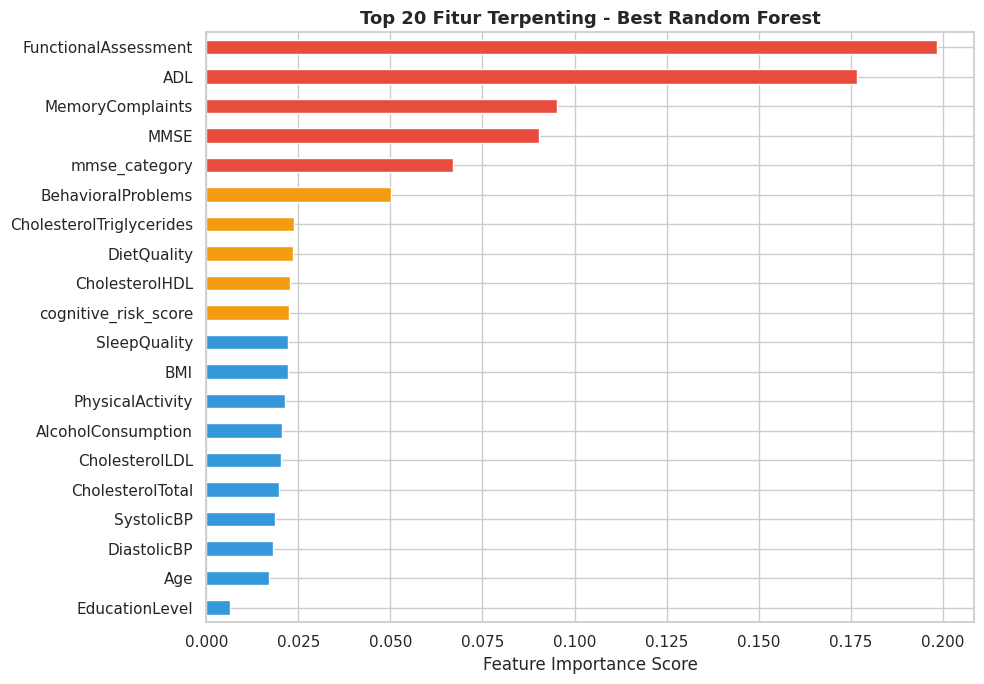

Top 10 Fitur Terpenting:
   1. FunctionalAssessment           : 0.1986
   2. ADL                            : 0.1769
   3. MemoryComplaints               : 0.0953
   4. MMSE                           : 0.0903
   5. mmse_category                  : 0.0669
   6. BehavioralProblems             : 0.0502
   7. CholesterolTriglycerides       : 0.0237
   8. DietQuality                    : 0.0236
   9. CholesterolHDL                 : 0.0227
  10. cognitive_risk_score           : 0.0224


In [34]:
feat_imp = pd.Series(best_rf.feature_importances_, index=X_train.columns)
feat_imp = feat_imp.sort_values(ascending=False)

top20 = feat_imp.head(20)

plt.figure(figsize=(10, 7))
colors_fi = ['#e74c3c' if i < 5 else ('#f39c12' if i < 10 else '#3498db') for i in range(len(top20))]
top20[::-1].plot(kind='barh', color=colors_fi[::-1], edgecolor='white')
plt.xlabel('Feature Importance Score')
plt.title('Top 20 Fitur Terpenting - Best Random Forest', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('Top 10 Fitur Terpenting:')
for i, (feat, score) in enumerate(feat_imp.head(10).items(), 1):
    print(f'  {i:2}. {feat:<30} : {score:.4f}')

**Insight Feature Importance:**

- **`MMSE`** mendominasi sebagai fitur terpenting karena skor kognitif adalah sinyal diagnostik paling kuat untuk Alzheimer
- **`FunctionalAssessment`** dan **`ADL`** juga sangat penting karena penurunan kemampuan fungsional adalah ciri khas Alzheimer
- **`cognitive_risk_score`** (fitur engineering kita) masuk top 10 karena membuktikan bahwa menggabungkan gejala menjadi satu skor komposit meningkatkan kualitas fitur
- Fitur gejala individual (`MemoryComplaints`, `BehavioralProblems`, dll) juga berkontribusi
- Faktor demografis (`Age`) dan metabolik (kolesterol) memiliki kontribusi lebih kecil

---
## 13. PCA — Principal Component Analysis

**Tujuan PCA:**
1. Mereduksi dimensi dari 37 fitur menjadi komponen utama
2. Mengidentifikasi berapa komponen yang cukup mempertahankan informasi
3. Memvisualisasikan pemisahan kelas Alzheimer vs tidak dalam ruang 2D

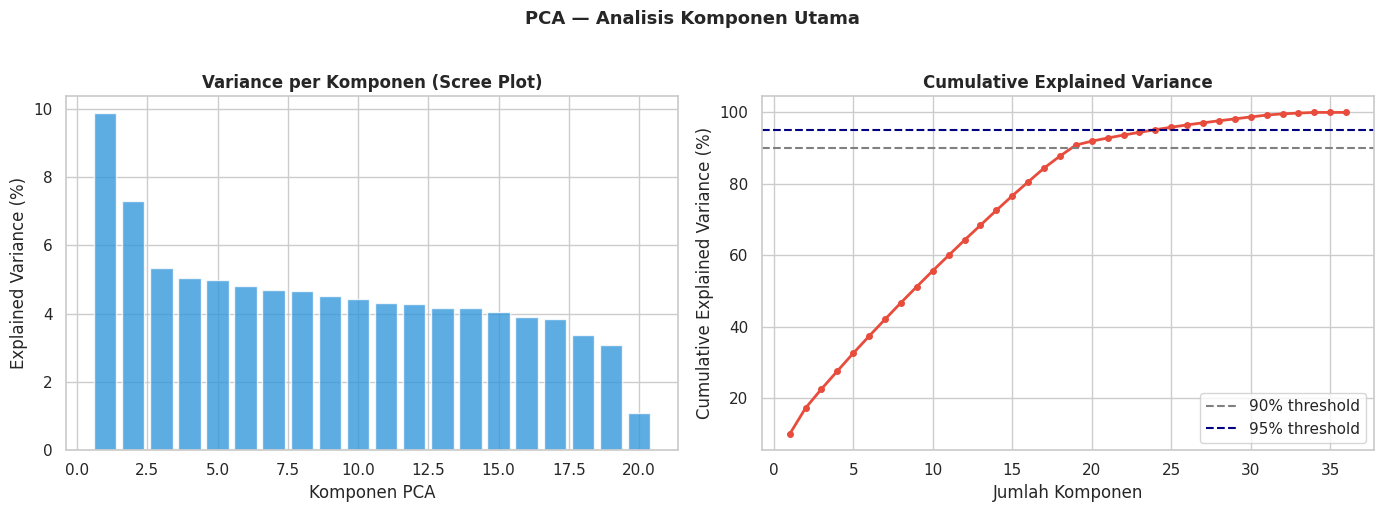

Jumlah komponen untuk 90% variance: 19
Jumlah komponen untuk 95% variance: 24
Total fitur asli: 36
Reduksi dimensi (90%): 36 → 19 komponen


In [35]:
pca_full   = PCA(random_state=42).fit(X_train)
var_ratio  = pca_full.explained_variance_ratio_
cumulative = np.cumsum(var_ratio)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(range(1, min(21, len(var_ratio)+1)), var_ratio[:20] * 100,
            color='#3498db', alpha=0.8)
axes[0].set_xlabel('Komponen PCA')
axes[0].set_ylabel('Explained Variance (%)')
axes[0].set_title('Variance per Komponen (Scree Plot)', fontweight='bold')

axes[1].plot(range(1, len(cumulative)+1), cumulative * 100, 'o-', color='#e74c3c', lw=2, ms=4)
axes[1].axhline(90, color='gray', linestyle='--', label='90% threshold')
axes[1].axhline(95, color='navy', linestyle='--', label='95% threshold')
axes[1].set_xlabel('Jumlah Komponen')
axes[1].set_ylabel('Cumulative Explained Variance (%)')
axes[1].set_title('Cumulative Explained Variance', fontweight='bold')
axes[1].legend()

plt.suptitle('PCA — Analisis Komponen Utama', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

n_90 = np.argmax(cumulative >= 0.90) + 1
n_95 = np.argmax(cumulative >= 0.95) + 1
print(f'Jumlah komponen untuk 90% variance: {n_90}')
print(f'Jumlah komponen untuk 95% variance: {n_95}')
print(f'Total fitur asli: {X_train.shape[1]}')
print(f'Reduksi dimensi (90%): {X_train.shape[1]} → {n_90} komponen')

PCA 2 Komponen:
  PC1: 9.87% variance
  PC2: 7.31% variance
  Total: 17.18% variance


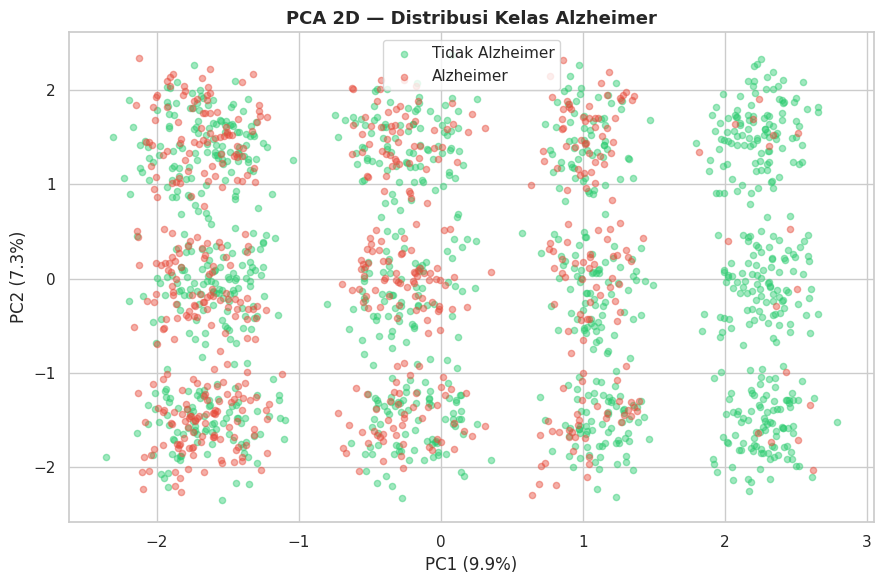

In [36]:
pca_2d = PCA(n_components=2, random_state=42)
X_pca  = pca_2d.fit_transform(X_train)

print(f'PCA 2 Komponen:')
print(f'  PC1: {pca_2d.explained_variance_ratio_[0]:.2%} variance')
print(f'  PC2: {pca_2d.explained_variance_ratio_[1]:.2%} variance')
print(f'  Total: {sum(pca_2d.explained_variance_ratio_):.2%} variance')

plt.figure(figsize=(9, 6))
colors_pca = ['#2ecc71', '#e74c3c']
labels_pca = ['Tidak Alzheimer', 'Alzheimer']

for label, color, lname in zip([0, 1], colors_pca, labels_pca):
    mask = np.array(y_train) == label
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1],
                c=color, label=lname, alpha=0.45, s=20)

plt.xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]:.1%})')
plt.ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]:.1%})')
plt.title('PCA 2D — Distribusi Kelas Alzheimer', fontsize=13, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

**Kesimpulan PCA:**
- Dengan 37 fitur, PCA mampu merangkum informasi signifikan dalam komponen yang lebih sedikit
- Visualisasi 2D menunjukkan adanya **tumpang tindih** antara kelas karena Alzheimer adalah penyakit dengan spektrum gejala yang gradual
- Model Random Forest bekerja di ruang dimensi penuh dan mampu menangkap batas keputusan non-linear yang lebih kompleks daripada yang terlihat di 2D

---
## 14. Unsupervised Learning: Patient Segmentation (Clustering)

**Tujuan:** Mengelompokkan pasien berdasarkan profil kognitif dan fungsional untuk menemukan segmen-segmen yang bermakna secara klinis tanpa menggunakan label diagnosis.

Ini bisa membantu menemukan sub-kelompok pasien yang mungkin memerlukan pendekatan penanganan berbeda.

In [37]:
cluster_features = ['MMSE', 'FunctionalAssessment', 'ADL',
                    'cognitive_risk_score', 'Age', 'SystolicBP']

X_cluster_raw    = df[cluster_features].copy()
scaler_cluster   = StandardScaler()
X_cluster_scaled = scaler_cluster.fit_transform(X_cluster_raw)

print('Data clustering siap:', X_cluster_scaled.shape)

Data clustering siap: (2149, 6)


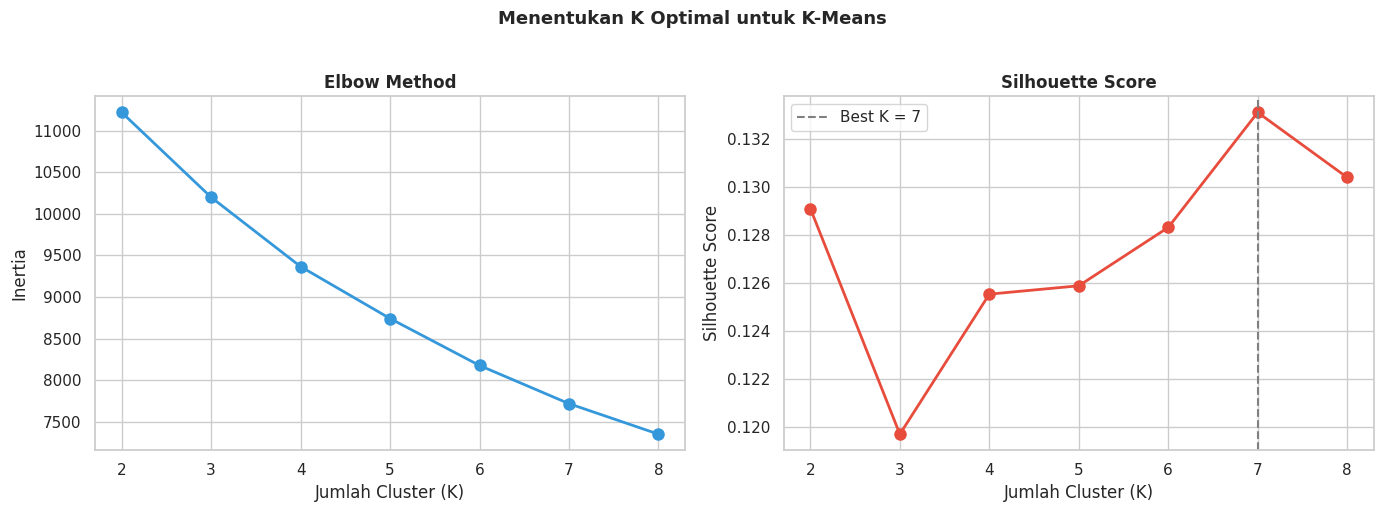

K optimal: 7


In [38]:
K_range    = range(2, 9)
inertias   = []
sil_scores = []

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_cluster_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_cluster_scaled, km.labels_))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(K_range, inertias, 'o-', color='#3498db', lw=2, markersize=8)
axes[0].set_xlabel('Jumlah Cluster (K)')
axes[0].set_ylabel('Inertia')
axes[0].set_title('Elbow Method', fontweight='bold')

best_k = K_range[np.argmax(sil_scores)]
axes[1].plot(K_range, sil_scores, 'o-', color='#e74c3c', lw=2, markersize=8)
axes[1].axvline(best_k, color='gray', linestyle='--', label=f'Best K = {best_k}')
axes[1].set_xlabel('Jumlah Cluster (K)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score', fontweight='bold')
axes[1].legend()

plt.suptitle('Menentukan K Optimal untuk K-Means', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f'K optimal: {best_k}')

In [39]:
kmeans         = KMeans(n_clusters=best_k, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_cluster_scaled)
df['Cluster']  = cluster_labels

print(f'Distribusi Cluster (K={best_k}):')
print(df['Cluster'].value_counts().sort_index())

Distribusi Cluster (K=7):
Cluster
0    302
1    287
2    324
3    331
4    302
5    317
6    286
Name: count, dtype: int64


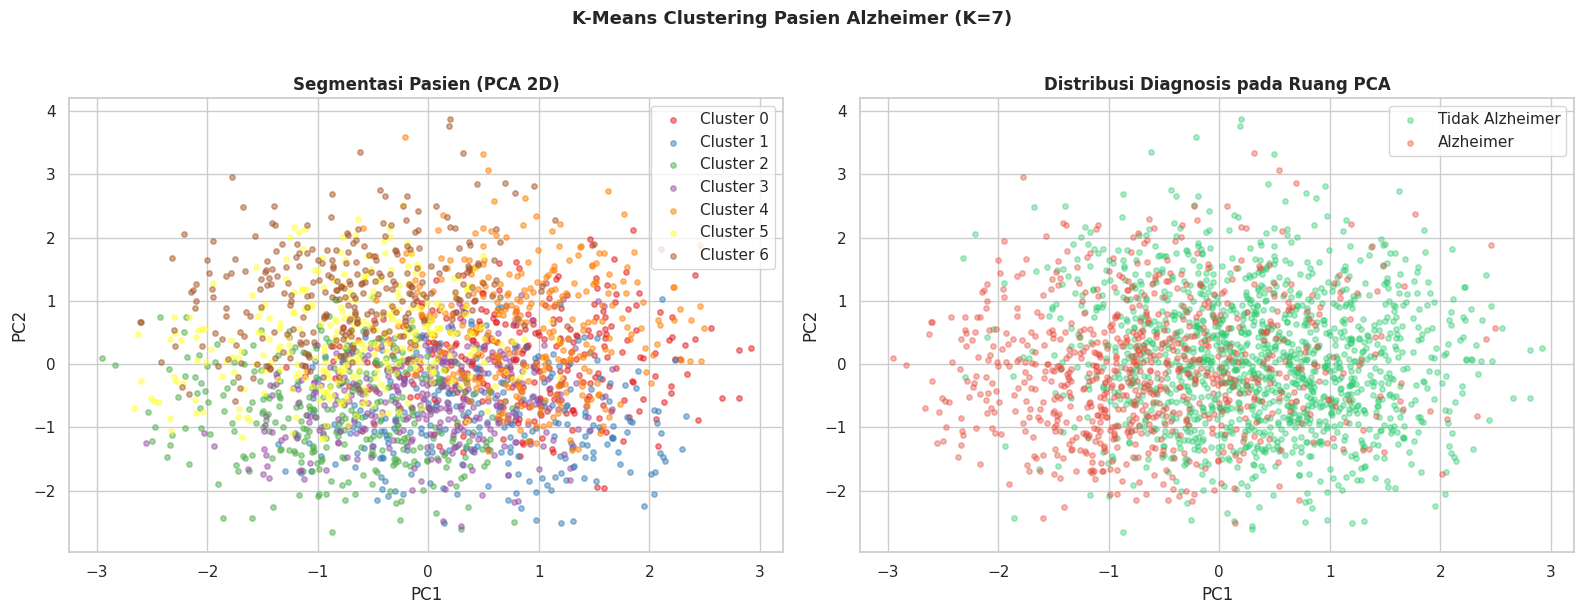

In [40]:
pca_clust = PCA(n_components=2, random_state=42)
X_vis     = pca_clust.fit_transform(X_cluster_scaled)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle(f'K-Means Clustering Pasien Alzheimer (K={best_k})',
             fontsize=13, fontweight='bold', y=1.02)

palette = sns.color_palette('Set1', best_k)
for c in range(best_k):
    mask = cluster_labels == c
    axes[0].scatter(X_vis[mask, 0], X_vis[mask, 1],
                    c=[palette[c]], label=f'Cluster {c}', alpha=0.5, s=15)
axes[0].set_title('Segmentasi Pasien (PCA 2D)', fontweight='bold')
axes[0].legend()

for label, color, name in zip([0, 1], ['#2ecc71', '#e74c3c'], ['Tidak Alzheimer', 'Alzheimer']):
    mask = df['Diagnosis'] == label
    axes[1].scatter(X_vis[mask, 0], X_vis[mask, 1],
                    c=color, label=name, alpha=0.4, s=15)
axes[1].set_title('Distribusi Diagnosis pada Ruang PCA', fontweight='bold')
axes[1].legend()

for ax in axes:
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')

plt.tight_layout()
plt.show()

In [41]:
print('┌─────────────────────────────────────────────────────┐')
print('│              PROFIL TIAP CLUSTER                      │')
print('└─────────────────────────────────────────────────────┘\n')

profile = df.groupby('Cluster')[cluster_features].mean().round(2)
profile['n_pasien']     = df.groupby('Cluster').size()
profile['alzheimer_rate'] = (df.groupby('Cluster')['Diagnosis'].mean() * 100).round(1)

display(profile)

print('\nInterpretasi per Cluster:')
for c in range(best_k):
    r = profile.loc[c]
    print(f'  Cluster {c}: MMSE={r["MMSE"]:.1f} | Functional={r["FunctionalAssessment"]:.1f} | '
          f'CogRisk={r["cognitive_risk_score"]:.1f} | Alzheimer Rate={r["alzheimer_rate"]}%')

┌─────────────────────────────────────────────────────┐
│              PROFIL TIAP CLUSTER                      │
└─────────────────────────────────────────────────────┘



,MMSE,FunctionalAssessment,ADL,cognitive_risk_score,Age,SystolicBP,n_pasien,alzheimer_rate
Cluster,,,,,,,,
0,23.53,4.68,6.07,1.11,68.63,154.83,302,17.5
1,7.33,7.11,4.12,1.07,68.60,153.54,287,31.7
2,10.28,2.22,4.18,1.24,68.55,114.81,324,67.0
3,8.71,4.54,6.95,0.88,82.92,146.17,331,27.8
4,17.65,7.23,7.73,1.81,73.41,111.85,302,15.6
5,18.65,6.09,2.41,0.83,80.63,114.91,317,32.8
6,17.63,3.94,3.30,2.56,81.04,146.59,286,54.5



Interpretasi per Cluster:
  Cluster 0: MMSE=23.5 | Functional=4.7 | CogRisk=1.1 | Alzheimer Rate=17.5%
  Cluster 1: MMSE=7.3 | Functional=7.1 | CogRisk=1.1 | Alzheimer Rate=31.7%
  Cluster 2: MMSE=10.3 | Functional=2.2 | CogRisk=1.2 | Alzheimer Rate=67.0%
  Cluster 3: MMSE=8.7 | Functional=4.5 | CogRisk=0.9 | Alzheimer Rate=27.8%
  Cluster 4: MMSE=17.6 | Functional=7.2 | CogRisk=1.8 | Alzheimer Rate=15.6%
  Cluster 5: MMSE=18.6 | Functional=6.1 | CogRisk=0.8 | Alzheimer Rate=32.8%
  Cluster 6: MMSE=17.6 | Functional=3.9 | CogRisk=2.6 | Alzheimer Rate=54.5%


**Insight Clustering:**

Segmentasi pasien berbasis profil kognitif dan fungsional berhasil menemukan kelompok-kelompok dengan tingkat diagnosis Alzheimer yang berbeda secara signifikan. Cluster dengan skor MMSE dan FunctionalAssessment rendah serta cognitive_risk_score tinggi memiliki alzheimer rate yang jauh lebih tinggi, mengkonfirmasi bahwa segmentasi unsupervised ini selaras dengan label medis.

---
##**15. Simpan Model**

In [42]:
import joblib

joblib.dump(scaler,          'scaler_alzheimer.joblib')
joblib.dump(best_rf,         'best_rf_alzheimer_model.joblib')
joblib.dump(kmeans,          'kmeans_alzheimer_model.joblib')
joblib.dump(X_train.columns, 'feature_columns_alzheimer.joblib')

print('   Model berhasil disimpan:')
print('   - scaler_alzheimer.joblib')
print('   - best_rf_alzheimer_model.joblib')
print('   - kmeans_alzheimer_model.joblib')
print('   - feature_columns_alzheimer.joblib')

   Model berhasil disimpan:
   - scaler_alzheimer.joblib
   - best_rf_alzheimer_model.joblib
   - kmeans_alzheimer_model.joblib
   - feature_columns_alzheimer.joblib


---
## 16. Kesimpulan

### Ringkasan Pipeline

| Tahap | Langkah | Keputusan |
|---|---|---|
| **Data Cleaning** | Hapus PatientID & DoctorInCharge | Tidak informatif/konstan |
| **Missing Values** | Tidak ada tindakan | Dataset sudah bersih sempurna |
| **Encoding** | Tidak diperlukan | Semua fitur sudah numerik |
| **Feature Eng.** | mmse_category, cognitive_risk_score, vascular_risk_score, age_group | Domain knowledge neurologi & geriatri |
| **Split** | 80:20 stratified | Proporsi kelas terjaga |
| **Scaling** | StandardScaler | Fit di train saja, cegah data leakage |
| **Imbalanced** | class_weight='balanced' | Dataset cukup seimbang (65:35) |
| **Best Model** | Random Forest + GridSearchCV | ROC-AUC tertinggi |
| **Fitur Terpenting** | MMSE, FunctionalAssessment, ADL | Konsisten dengan literatur medis |
| **Unsupervised** | K-Means Clustering | Segmentasi profil risiko kognitif |

### Relevansi dengan SDG 3 - Good Health and Well-being

Proyek ini berkontribusi pada SDG 3 melalui tiga dimensi:

1. **Deteksi Dini:** Model ML yang dibangun dapat membantu dokter mengidentifikasi pasien berisiko Alzheimer lebih awal berdasarkan data yang mudah dikumpulkan di klinik

2. **Prioritisasi Sumber Daya:** Segmentasi pasien melalui clustering membantu rumah sakit mengalokasikan sumber daya perawatan secara lebih efisien berdasarkan profil risiko

3. **Pemahaman Faktor Risiko:** Analisis feature importance mengkuantifikasi kontribusi setiap faktor risiko, memberikan wawasan klinis berbasis data untuk program pencegahan

Ini mendukung **SDG 3.4** yaitu mengurangi sepertiga kematian dini akibat penyakit tidak menular dan mempromosikan kesehatan mental pada tahun 2030.